# Examples of loading comparison results

Load a run directory produced by `run.py` and compare all solver results.

```
python run.py --map small_sufficient --solvers all --output results/runs
```

Then set `RUN_DIR` below to the timestamped sub-folder (e.g. `results/runs/20250101_120000`).

Result tags use the new naming scheme: `{method_key}_{map_size}_{budget}`  
e.g. `deepseek_Joint_small_sufficient`, `Heuristic_CPSAT_small_sufficient`

In [1]:
# import modules
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from pathlib import Path
from run import load_results, MAP_FACTORIES
from visualization import compare_table, plot_comparison

In [2]:

# Load configurations and results
RUN_DIR = 'results/runs/20260403_194757'

# Load all results from the run directory
results = load_results(RUN_DIR)
print(f'Loaded {len(results)} result(s) from {RUN_DIR}')
print('Tags:', sorted(results.keys()))

Loaded 30 result(s) from results/runs/20260403_194757
Tags: ['CPSAT_Joint_small_sufficient', 'GA_CPSAT_small_sufficient', 'GA_Heuristic_small_sufficient', 'Heuristic_CPSAT_small_sufficient', 'Heuristic_Joint_small_sufficient', 'Heuristic_claude_small_sufficient', 'Heuristic_deepseek_small_sufficient', 'Heuristic_gemini_small_sufficient', 'Heuristic_gpt_small_sufficient', 'Heuristic_qwen_small_sufficient', 'claude_CPSAT_small_sufficient', 'claude_Heuristic_small_sufficient', 'claude_Joint_small_sufficient', 'claude_claude_small_sufficient', 'deepseek_CPSAT_small_sufficient', 'deepseek_Heuristic_small_sufficient', 'deepseek_Joint_small_sufficient', 'deepseek_deepseek_small_sufficient', 'gemini_CPSAT_small_sufficient', 'gemini_Heuristic_small_sufficient', 'gemini_Joint_small_sufficient', 'gemini_gemini_small_sufficient', 'gpt_CPSAT_small_sufficient', 'gpt_Heuristic_small_sufficient', 'gpt_Joint_small_sufficient', 'gpt_gpt_small_sufficient', 'qwen_CPSAT_small_sufficient', 'qwen_Heuristic_s

## Summary Table

In [3]:
import json
config_path = Path(RUN_DIR) / 'config.json'
if config_path.exists():
    with open(config_path) as f:
        config = json.load(f)
    print('Run config:')
    for k, v in config.items():
        print(f'  {k}: {v}')

Run config:
  run_id: 20260403_194757
  maps: ['small_sufficient']
  solvers: ['Heuristic_Joint', 'CPSAT_Joint', 'Heuristic_CPSAT', 'GA_Heuristic', 'GA_CPSAT', 'Agent_Joint', 'Heuristic_Agent', 'Agent_Heuristic', 'Agent_CPSAT', 'Agent_Agent']
  models: ['deepseek/deepseek-v3.2', 'openai/gpt-5.4', 'qwen/qwen3.5-35b-a3b', 'google/gemini-3-flash-preview', 'anthropic/claude-sonnet-4.6']
  agent_calls: 20
  route_calls: 10
  minimize_cost: True
  ga_pop: 30
  ga_gens: 50
  cpsat_time_s: 300.0
  timestamp: 20260403_194757


In [4]:
df_all = compare_table(results)
# Optional:save as CSV for easier viewing
# df_all.to_csv( f'results/tables/summary_{config['maps'][0]}.csv', index=False)

In [5]:
display(df_all[['Method', 'Map', 'Budget', 'Model', 
                'Makespan', 'Road cost', 'Delivered', 'Status',
                'Tool calls', 'Route runs', 'Total calls', 'Time (s)']
               ].sort_values(by=['Makespan', 'Road cost']))

,Method,Map,Budget,Model,Makespan,Road cost,Delivered,Status,Tool calls,Route runs,Total calls,Time (s)
0,CPSAT_Joint,small,sufficient,-,11,68,True,OPTIMAL,NaN,NaN,NaN,3.804
24,gpt_Joint,small,sufficient,gpt,11,68,True,AGENT_OPTIMAL,8.0,NaN,NaN,76.690
12,claude_Joint,small,sufficient,claude,11,86,True,AGENT_OPTIMAL,18.0,NaN,NaN,319.310
10,claude_CPSAT,small,sufficient,claude,11,119,True,AGENT_OPTIMAL,20.0,NaN,NaN,114.480
22,gpt_CPSAT,small,sufficient,gpt,13,34,True,AGENT_OPTIMAL,11.0,NaN,NaN,35.390
14,deepseek_CPSAT,small,sufficient,deepseek,13,42,True,AGENT_OPTIMAL,20.0,NaN,NaN,333.740
16,deepseek_Joint,small,sufficient,deepseek,13,52,True,AGENT_OPTIMAL,19.0,NaN,NaN,729.910
1,GA_CPSAT,small,sufficient,-,13,53,True,HEURISTIC,NaN,NaN,NaN,61.344
2,GA_Heuristic,small,sufficient,-,13,53,True,HEURISTIC,NaN,NaN,NaN,0.457
23,gpt_Heuristic,small,sufficient,gpt,13,55,True,AGENT_OPTIMAL,11.0,NaN,NaN,19.280


## Side-by-Side Road Layouts

In [ ]:
map_name = 'small_sufficient' # change the map size as needed
sim_orig = MAP_FACTORIES[map_name]()

entries = [(tag, entry)
           for tag, entry in sorted(results.items())
           if tag.endswith(f'_{map_name}') and entry['sim'] is not None]
if not entries:
    print(f'No sim objects for map {map_name} (pkl files missing?)')


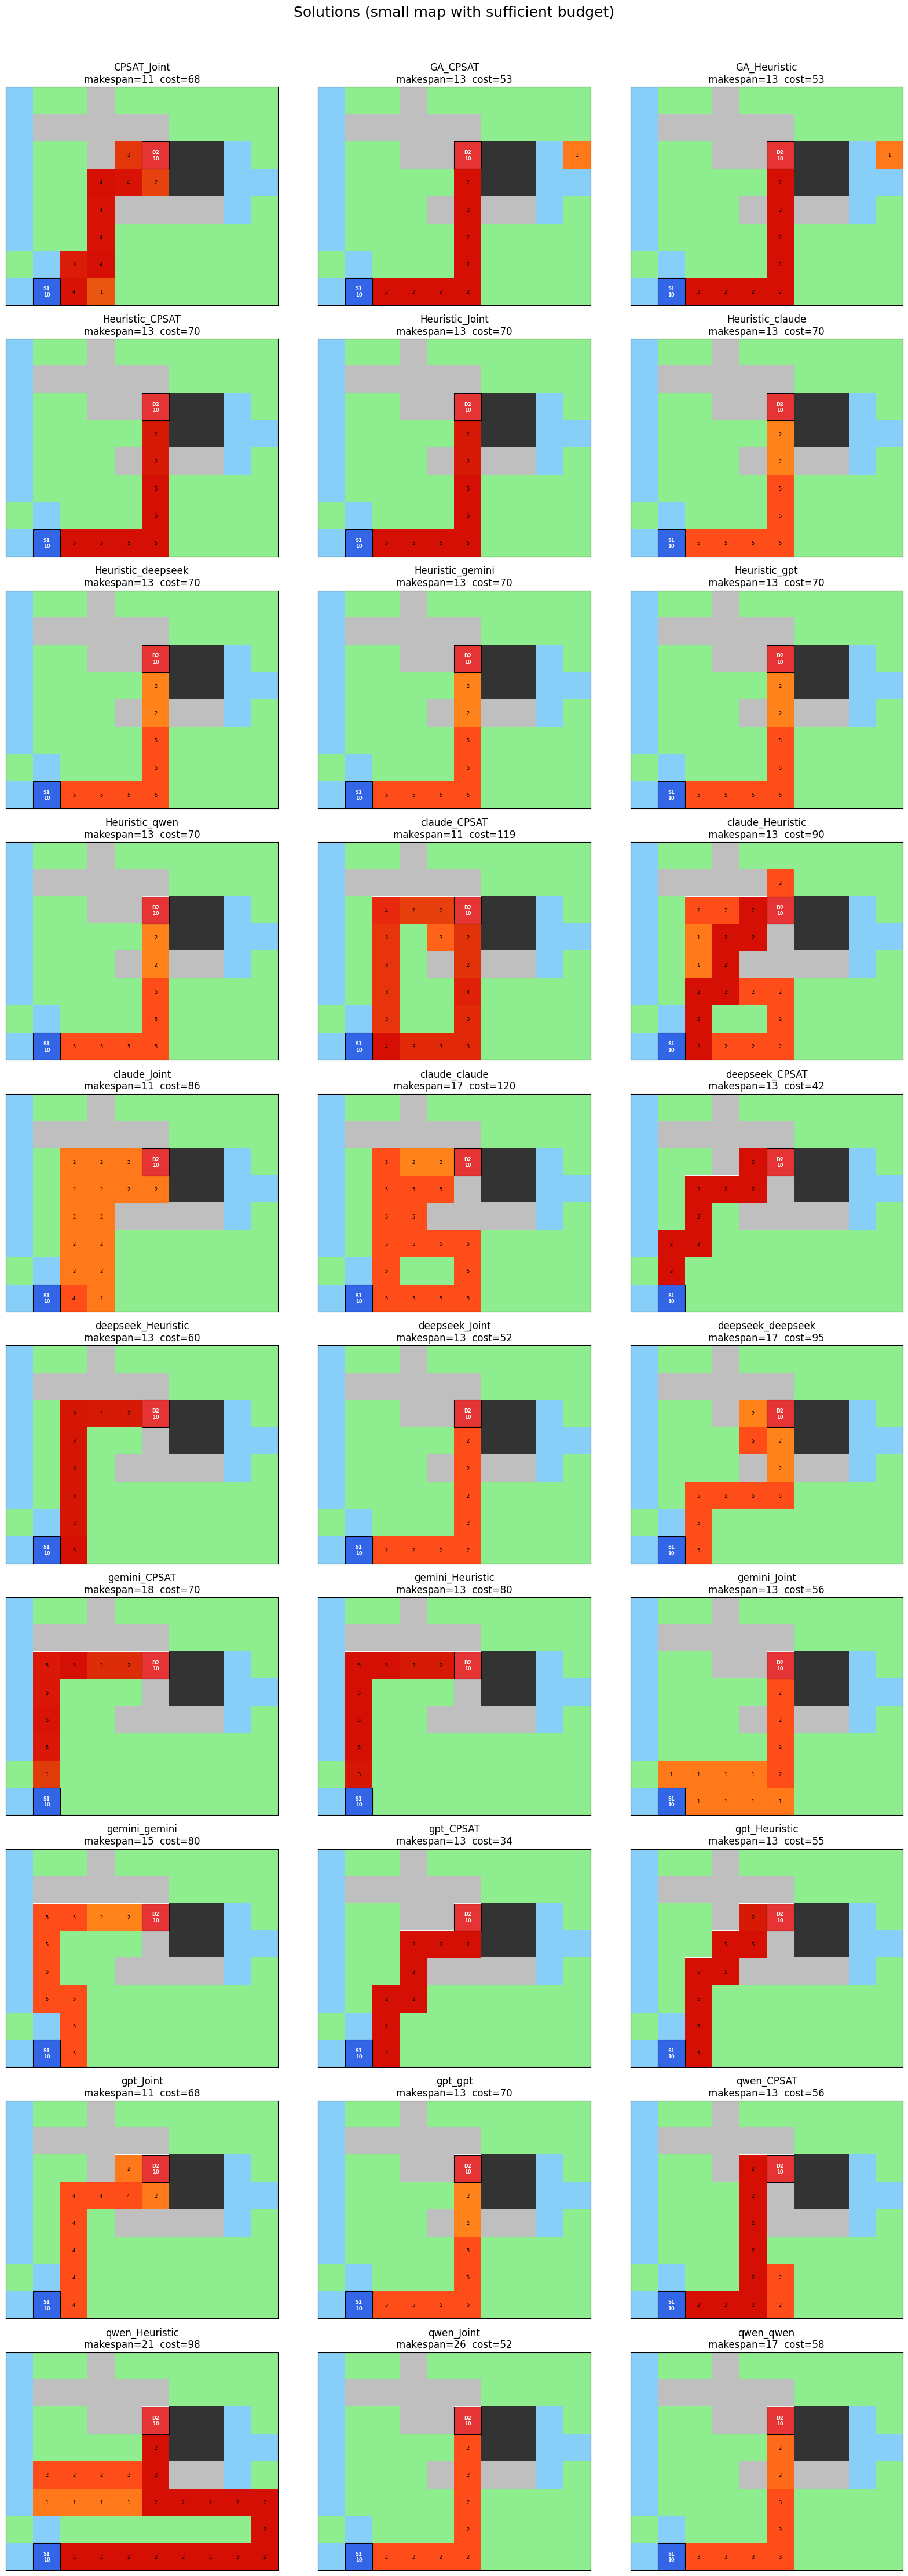

In [12]:

sims_meta = [(tag, entry['sim'], entry['meta']) for tag, entry in entries]
plot_comparison(
    sims_meta,
    sim_orig=sim_orig,   # used to reconstruct agent road networks from snapshots
    title= 'Solutions (small map with sufficient budget)',
    cols=3,
    snap='final',        # 'final' = submitted solution; 'best' = best during loop
)